In [1]:
# Import libraries
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import joblib

from src.train import load_feature_data, split_data, train_and_evaluate, select_best_model
from src.evaluate import plot_roc_curve, plot_confusion
from src.config import MODELS_DIR, FIGURES_DIR

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [2]:
# Load data
df = load_feature_data()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,ChurnFlag,tenure_group,avg_monthly_value,num_services,has_protection,contract_risk,is_electronic_check,is_new_customer,is_high_value
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,0,0-12,14.925000,1,0,2,1,1,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,0,24-48,53.985714,3,1,1,0,0,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Yes,1,0-12,36.050000,3,1,2,0,1,0
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,0,24-48,40.016304,3,1,1,0,0,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Yes,1,0-12,50.550000,1,0,2,1,1,1


In [3]:
# split data
X_train, X_test, y_train, y_test = split_data(df)

In [4]:
# train models
results = train_and_evaluate(X_train, X_test, y_train, y_test)

logistic AUC: 0.8461
random_forest AUC: 0.8213


In [5]:
# Select best model
best_model = select_best_model(results)

Best model: logistic


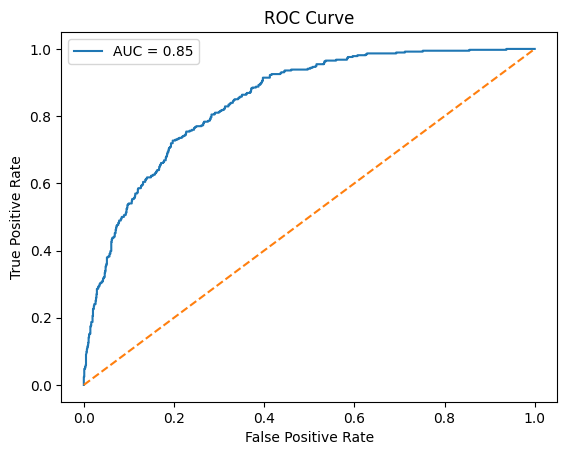

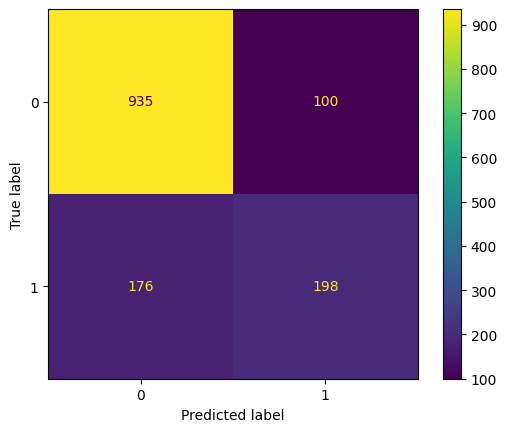

In [6]:
plot_roc_curve(best_model, X_test, y_test, FIGURES_DIR / "roc_curve.png")
plot_confusion(best_model, X_test, y_test, FIGURES_DIR / "confusion_matrix.png")

In [7]:
model_path = MODELS_DIR / "churn_model.joblib"
joblib.dump(best_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: /mnt/c/Users/mbaik/Desktop/Alaid/Projects/telco-churn-intelligence/models/churn_model.joblib


## Model Summary

Two models were trained and evaluated:

- Logistic Regression (baseline)
- Random Forest (non-linear model)

Evaluation metric:
- ROC-AUC was used as the primary metric due to class imbalance

The best-performing model was selected based on AUC and saved for deployment.

Key observations:
- Tree-based models generally capture non-linear relationships better
- Logistic regression provides interpretability